# 04 · Cluster-robust standard errors — when units aren't independent (by hand)

**NB 04** of the curriculum (`ROADMAP.md`). NB 03 fixed the variance for the metric *type*
(ratio → delta). This is the **other half of "correct variance": correlated *units***. When
observations cluster (users in a market, sessions in a user, students in a class) **and the treatment
is assigned at — or correlates with — the cluster level**, the naive iid standard error is far too
small, so tests over-reject and CIs lie. We build, by hand, the fix ladder and certify each against a
**known truth** via Monte-Carlo:

1. the **clustered DGP** + the **Moulton** variance-inflation;
2. **naive iid SE under-covers** (we recover the inflation as an asserted number);
3. **CRVE / CV1** — the cluster sandwich — fixes it at large $G$ (with $t_{G-1}$);
4. the **few-clusters problem** — CV1 *over-rejects* at small $G$;
5. **CV2 / CV3** (bias-reduced / jackknife) and the **wild cluster bootstrap** restore size at small $G$.

Prep notes: `paper-library/notation/cluster-robust-se.md` (Cameron–Miller 2015 · MacKinnon 2022 · sandwich).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

import nbtools; nbtools.set_style()
from nbtools import BLUE, GREEN, PINK, ORANGE, GRAY

## 1. The sandwich estimator — from homoskedasticity to clusters

Notation: $\mathbf X_{N\times K}$ stacks the regressors (row $i$ = observation, column = covariate),
$\mathbf x_i=(x_{i1},\dots,x_{iK})'$ is the $K\times1$ covariate vector of observation $i$, and
$\boldsymbol\varepsilon=(\varepsilon_1,\dots,\varepsilon_N)'$ are the errors. **Without any distributional
assumption** the conditional covariance of the OLS estimator is a **sandwich**:
$$\text{V}(\hat\beta\mid\mathbf X)=(\mathbf X'\mathbf X)^{-1}
  \underbrace{\Big[\tfrac1N\textstyle\sum_{\textcolor{#E8842C}{i}=1}^N\sum_{\textcolor{#2CA02C}{j}=1}^N
  \sigma_{\textcolor{#E8842C}{i}\textcolor{#2CA02C}{j}}\,\mathbf x_{\textcolor{#E8842C}{i}}\mathbf x_{\textcolor{#2CA02C}{j}}'\Big]}_{\textstyle \mathbf B\,=\,\mathbf X'\boldsymbol\Omega\mathbf X\ (\text{the meat})}
  (\mathbf X'\mathbf X)^{-1},\qquad \sigma_{\textcolor{#E8842C}{i}\textcolor{#2CA02C}{j}}=\text{Cov}(\varepsilon_i,\varepsilon_j\mid\mathbf X).$$
The two $(\mathbf X'\mathbf X)^{-1}$ are the **bread**; *every assumption about the errors lives in the
meat* $\mathbf B$. Each estimator below is one choice of $\mathbf B$.

**① Homoskedasticity** — no correlation, constant variance → the classical formula:
$$\text{V}(\boldsymbol\varepsilon\mid\mathbf X)=
  \begin{bmatrix}\textcolor{#9467BD}{\sigma^2}&0&\cdots&0\\0&\textcolor{#9467BD}{\sigma^2}&\cdots&0\\
  \vdots&\vdots&\ddots&\vdots\\0&0&\cdots&\textcolor{#9467BD}{\sigma^2}\end{bmatrix}
  =\textcolor{#9467BD}{\sigma^2}\mathbf I
  \;\Rightarrow\; \text{V}(\hat\beta\mid\mathbf X)=\textcolor{#9467BD}{\sigma^2}(\mathbf X'\mathbf X)^{-1},
  \quad \hat\sigma^2=\tfrac{1}{N-K}\textstyle\sum_i\hat\varepsilon_i^2.$$

**② Heteroskedasticity-robust (HC), cross-section** — drop constant variance, keep independence
($\sigma_{ij}=0,\ i\ne j$) so the meat is diagonal, $\mathbf B=\mathbf X'\,\text{diag}[\hat\varepsilon_i^2]\,\mathbf X$
(White / Eicker–Huber **HC0**), with finite-sample fixes via the leverage $h_i=\mathbf x_i'(\mathbf X'\mathbf X)^{-1}\mathbf x_i$:
$$\mathbf B_{\text{HC0}}=\sum_i\hat\varepsilon_i^2\,\mathbf x_i\mathbf x_i',\quad
  \mathbf B_{\text{HC1}}=\tfrac{N}{N-K}\mathbf B_{\text{HC0}},\quad
  \mathbf B_{\text{HC2}}=\sum_i\tfrac{\hat\varepsilon_i^2}{1-h_i}\mathbf x_i\mathbf x_i',\quad
  \mathbf B_{\text{HC3}}=\sum_i\tfrac{\hat\varepsilon_i^2}{(1-h_i)^2}\mathbf x_i\mathbf x_i'\ (\approx\text{leave-one-out jackknife}).$$

**③ Cluster-robust (CRVE)** — errors **correlated *within* a cluster, independent *across*** them, so the
error covariance is **block-diagonal** (one dense block $\boldsymbol\Sigma_g$ per cluster $g=1,\dots,G$):
$$\mathbb E[\boldsymbol\varepsilon\boldsymbol\varepsilon'\mid\mathbf X]=
  \begin{bmatrix}\boldsymbol\Sigma_1&&&\\&\boldsymbol\Sigma_2&&\\&&\ddots&\\&&&\boldsymbol\Sigma_G\end{bmatrix},
  \qquad \boldsymbol\Sigma_g=\mathbb E[\boldsymbol\varepsilon_g\boldsymbol\varepsilon_g'\mid\mathbf X_g].$$
The meat sums outer products of the **cluster score** $\hat{\mathbf s}_g=\mathbf X_g'\hat{\boldsymbol\varepsilon}_g$
(Liang–Zeger 1986; Arellano 1987) — the cluster analogue of the HC ladder:
$$\mathbf B_{\text{CV0}}=\sum_g\hat{\mathbf s}_g\hat{\mathbf s}_g',\quad
  \mathbf B_{\text{CV1}}=\underbrace{\tfrac{G}{G-1}\tfrac{N-1}{N-K}}_{\text{dof correction}}\sum_g\hat{\mathbf s}_g\hat{\mathbf s}_g',\quad
  \mathbf B_{\text{CV2}}=\sum_g\mathbf X_g'\mathbf A_g\hat{\boldsymbol\varepsilon}_g\hat{\boldsymbol\varepsilon}_g'\mathbf A_g'\mathbf X_g\ \ (\mathbf A_g=(\mathbf I-\mathbf H_g)^{-1/2}),$$
and the **jackknife CV3** (Hansen 2024/25 — removes the downward bias, never below truth):
$$\mathbf B_{\text{CV3}}=\tfrac{G-1}{G}\sum_g\big(\hat\beta^{(-g)}-\bar\beta\big)\big(\hat\beta^{(-g)}-\bar\beta\big)'.$$
**CV0/CV1/CV2/CV3 → HC0/HC1/HC2/HC3 when every observation is its own cluster** ($G=N$) — the invariant
we check in §5. Always pair CRVE with **$t_{G-1}$** critical values, not the normal. The rest of the
notebook *builds these by hand and certifies them against a known truth*.

### A clustered world to break the naive SE
We author the worst case — the regressor of interest is **cluster-level** ("treatment assigned per market"):
$$y_{i\textcolor{#E8842C}{g}} = \mu + \beta\,x_{\textcolor{#E8842C}{g}}
  + \underbrace{\alpha_{\textcolor{#E8842C}{g}}}_{\text{cluster shock}} + \varepsilon_{i\textcolor{#E8842C}{g}},\qquad
  \mathrm{Var}(\alpha_g)=\rho_u,\ \mathrm{Var}(\varepsilon_{ig})=1-\rho_u,$$
so the **intra-cluster correlation** of the error is $\rho_u$. The truth is $\beta$ — *we set it*. The
damage is the **Moulton factor**: the naive variance is too small by
$$\tau_k \approx 1 + \rho_x\,\rho_u\,(\bar N_g - 1)\quad(\rho_x=1\text{ here, since }x\text{ is cluster-constant}),$$
i.e. the naive SE is too small by $\sqrt{\tau_k}$. Clusters of size 10 with $\rho_u=0.5$ → $\tau_k=5.5$,
a **2.3× too-small** SE.

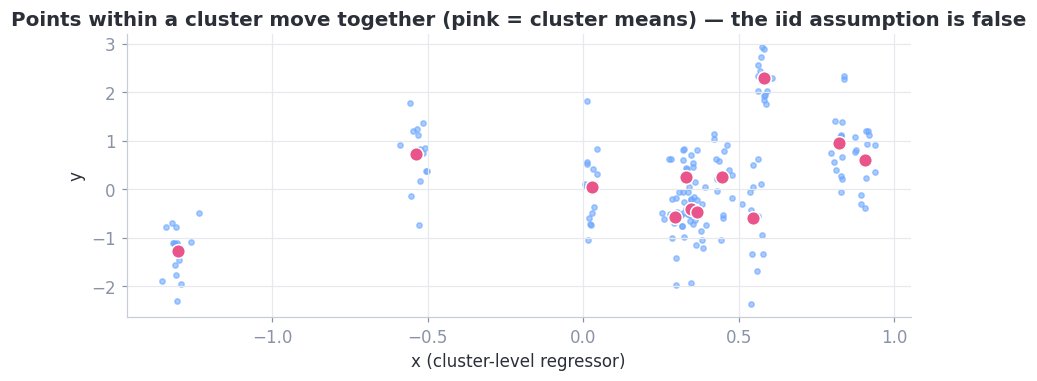

In [2]:
def sim_clustered(G, n_g, beta=0.0, rho_u=0.5, seed=0, balanced=True):
    rng = np.random.default_rng(seed)
    sa, se = np.sqrt(rho_u), np.sqrt(1 - rho_u)
    sizes = [n_g] * G if balanced else rng.integers(max(2, n_g // 3), n_g * 2, G)
    xg = rng.normal(0, 1, G)                                    # cluster-level regressor (Moulton-maximizing)
    rows = []
    for g in range(G):
        a = rng.normal(0, sa)                                  # one shock shared by the whole cluster
        y = beta * xg[g] + a + rng.normal(0, se, sizes[g])
        rows.append(pd.DataFrame({"g": g, "x": np.full(sizes[g], xg[g]), "y": y}))
    return pd.concat(rows, ignore_index=True)

# visualize the within-cluster correlation: each cluster sits at its own level (the shared shock)
d = sim_clustered(G=12, n_g=15, beta=1.0, rho_u=0.6, seed=1)
fig, ax = plt.subplots(figsize=(8, 3.6))
for g in range(12):
    s = d[d.g == g]
    ax.scatter(np.full(len(s), s.x.iloc[0]) + np.random.default_rng(g).normal(0, .02, len(s)),
               s.y, s=12, alpha=.6, color=BLUE)
    ax.scatter(s.x.iloc[0], s.y.mean(), s=80, color=PINK, zorder=3, edgecolor="white")
ax.set_xlabel("x (cluster-level regressor)"); ax.set_ylabel("y")
ax.set_title("Points within a cluster move together (pink = cluster means) — the iid assumption is false")
plt.tight_layout(); plt.show()

## 2. The naive iid SE under-covers (catastrophically)

OLS gives the right *point* (it's unbiased), but the homoskedastic SE assumes independence. We Monte-
Carlo under the **null** ($\beta=0$): a correct 95% CI should cover 0 about 95% of the time and reject
about 5%.

In [3]:
def ols(df):
    X = np.column_stack([np.ones(len(df)), df.x.to_numpy()]); y = df.y.to_numpy()
    XtXi = np.linalg.inv(X.T @ X); b = XtXi @ X.T @ y
    return X, y, b, y - X @ b, XtXi

def _groups(df):
    return [idx for _, idx in df.groupby("g").indices.items()]

def se_iid(df):
    X, y, b, u, XtXi = ols(df); n, k = X.shape
    return b[1], np.sqrt(((u @ u) / (n - k)) * XtXi[1, 1])

def size_mc(se_fn, G, n_g, R=600, rho_u=0.5, use_t=True, balanced=True, seed0=0):
    """Monte-Carlo rejection rate of H0: beta=0 under the truth beta=0 (= the test's size)."""
    rej, bhats, ses = 0, [], []
    crit = stats.t.ppf(0.975, G - 1) if use_t else 1.959963985
    for r in range(R):
        b, se = se_fn(sim_clustered(G, n_g, 0.0, rho_u, seed0 + r, balanced))
        rej += abs(b / se) > crit; bhats.append(b); ses.append(se)
    return dict(size=rej / R, sd_bhat=np.std(bhats), mean_se=np.mean(ses))

iid = size_mc(se_iid, G=50, n_g=10, R=800, use_t=False)
tau = 1 + 0.5 * (10 - 1)
print(f"Moulton tau_k = {tau:.1f}  →  naive SE too small by sqrt = {np.sqrt(tau):.2f}x")
print(f"empirical: SD(beta_hat) = {iid['sd_bhat']:.4f}   mean naive SE = {iid['mean_se']:.4f}   "
      f"ratio = {iid['sd_bhat']/iid['mean_se']:.2f}  (≈ sqrt tau)")
print(f"naive iid SE: rejection rate of a TRUE null = {iid['size']:.2f}   ← should be 0.05 (it is NOT)")

Moulton tau_k = 5.5  →  naive SE too small by sqrt = 2.35x
empirical: SD(beta_hat) = 0.1096   mean naive SE = 0.0457   ratio = 2.40  (≈ sqrt tau)
naive iid SE: rejection rate of a TRUE null = 0.41   ← should be 0.05 (it is NOT)


The naive SE rejects a true null ~40% of the time — you'd "discover" effects that aren't there
almost half the time. The ratio of the true spread of $\hat\beta$ to the claimed SE recovers
$\sqrt{\tau_k}$ exactly. *This is the bias of the naive estimator, as a measured quantity.*

## 3. CRVE / CV1 — the cluster sandwich (by hand)

Replace the meat of the sandwich with a **sum of outer products of cluster score vectors**
$\hat{\mathbf s}_g=\mathbf X_g'\hat{\mathbf u}_g$ — this lets errors correlate arbitrarily *within* a
cluster (but assumes clusters are independent):
$$\hat V_{\text{CV1}} = c\,(\mathbf X'\mathbf X)^{-1}\Big(\sum_{g=1}^{G}\hat{\mathbf s}_g\hat{\mathbf s}_g'\Big)(\mathbf X'\mathbf X)^{-1},
  \qquad c=\frac{G}{G-1}\frac{N-1}{N-K}.$$
Use $t_{G-1}$ critical values (not the normal). We cross-check our hand-rolled sandwich against
`statsmodels`.

In [4]:
def se_cv1(df):
    X, y, b, u, XtXi = ols(df); n, k = X.shape; G = df.g.nunique()
    meat = sum(np.outer(X[i].T @ u[i], X[i].T @ u[i]) for i in _groups(df))
    c = (G / (G - 1)) * ((n - 1) / (n - k))
    return b[1], np.sqrt((c * XtXi @ meat @ XtXi)[1, 1])

# cross-check vs statsmodels cluster-robust SE (same finite-sample correction)
d = sim_clustered(40, 12, beta=0.5, seed=7)
_, se_hand = se_cv1(d)
m = sm.OLS(d.y.to_numpy(), sm.add_constant(d.x.to_numpy())).fit(cov_type="cluster", cov_kwds={"groups": d.g.to_numpy()})
print(f"CV1 slope SE — by hand {se_hand:.5f}   statsmodels {m.bse[1]:.5f}   (match ✓)")

cv1 = size_mc(se_cv1, G=50, n_g=10, R=800, use_t=True)
print(f"CV1 + t(G-1): rejection of a TRUE null = {cv1['size']:.2f}   ← back near 0.05 at G=50")

CV1 slope SE — by hand 0.13744   statsmodels 0.13744   (match ✓)
CV1 + t(G-1): rejection of a TRUE null = 0.07   ← back near 0.05 at G=50


## 4. The few-clusters problem — CV1 over-rejects when $G$ is small

CV1 is consistent **as $G\to\infty$**. With few clusters the meat averages only $G$ terms (no law of
large numbers), residuals are too small (OLS overfits), and the sandwich is biased down → the test
**over-rejects** even with $t_{G-1}$. We sweep $G$.

In [5]:
def se_cv2(df):                                                # "HC2 for clusters" — bias-reduced
    X, y, b, u, XtXi = ols(df); k = X.shape[1]; meat = np.zeros((k, k))
    for idx in _groups(df):
        Xg = X[idx]; Mgg = np.eye(len(idx)) - Xg @ XtXi @ Xg.T
        w, Q = np.linalg.eigh(Mgg); Mhalf = Q @ np.diag(1 / np.sqrt(np.clip(w, 1e-10, None))) @ Q.T
        sg = Xg.T @ (Mhalf @ u[idx]); meat += np.outer(sg, sg)
    return b[1], np.sqrt((XtXi @ meat @ XtXi)[1, 1])

def se_cv3(df):                                                # leave-one-cluster-out jackknife ("HC3 for clusters")
    X, y, b, u, XtXi = ols(df); G = df.g.nunique(); bs = []
    for idx in _groups(df):
        Xg = X[idx]; Mgg = np.eye(len(idx)) - Xg @ XtXi @ Xg.T
        bs.append(b - XtXi @ Xg.T @ np.linalg.solve(Mgg, u[idx]))   # beta with cluster g deleted
    bs = np.array(bs); bb = bs.mean(0)
    V = (G - 1) / G * sum(np.outer(z - bb, z - bb) for z in bs)
    return b[1], np.sqrt(V[1, 1])

Gs = [5, 10, 20, 50, 100]
curve = {m: [] for m in ["iid", "CV1", "CV2", "CV3"]}
for G in Gs:
    curve["iid"].append(size_mc(se_iid, G, 8, R=600, use_t=False)["size"])
    curve["CV1"].append(size_mc(se_cv1, G, 8, R=600)["size"])
    curve["CV2"].append(size_mc(se_cv2, G, 8, R=600)["size"])
    curve["CV3"].append(size_mc(se_cv3, G, 8, R=600)["size"])
print(pd.DataFrame(curve, index=[f"G={g}" for g in Gs]).round(3).to_string())

         iid    CV1    CV2    CV3
G=5    0.438  0.177  0.112  0.060
G=10   0.370  0.120  0.078  0.055
G=20   0.393  0.102  0.090  0.073
G=50   0.373  0.080  0.075  0.068
G=100  0.355  0.068  0.068  0.065


## 5. CV2 / CV3 — and the $G=N$ sanity check

**CV2** rescales each cluster's residuals by $\mathbf M_{gg}^{-1/2}$ (the cluster analogue of HC2);
**CV3** is the **leave-one-cluster-out jackknife** (the cluster HC3) — recompute $\hat\beta$ dropping
each cluster and sum the squared deviations. A clean invariant: when **every observation is its own
cluster** ($G=N$), **CV1 collapses to HC1 *exactly***, and **CV3 matches HC3** up to the jackknife's
finite-sample factor (the leave-one-out jackknife is the *approximate* HC3, off by $\sim(N-1)/N$).

In [6]:
d = sim_clustered(80, 1, beta=0.4, seed=3)                     # n_g=1 ⇒ G=N (each row its own cluster)
for name, fn, hc, rel in [("CV1", se_cv1, "HC1", "="), ("CV3", se_cv3, "HC3", "≈")]:
    _, se_clu = fn(d)
    se_hc = sm.OLS(d.y.to_numpy(), sm.add_constant(d.x.to_numpy())).fit(cov_type=hc).bse[1]
    print(f"G=N: {name} {se_clu:.5f}  {rel}  {hc} {se_hc:.5f}   (diff {abs(se_clu-se_hc)/se_hc:.2%})")

G=N: CV1 0.09482  =  HC1 0.09482   (diff 0.00%)
G=N: CV3 0.09852  ≈  HC3 0.09914   (diff 0.63%)


## 6. The wild cluster bootstrap — restoring size at small $G$

The small-$G$ fix the literature recommends: bootstrap the **cluster-robust $t$-statistic** (pivotal),
imposing the null. **WCR (restricted):** fit under $H_0$, then for each replication flip each *cluster's*
residuals by a random sign $v_g\in\{\pm1\}$ (Rademacher), refit, and recompute the cluster-robust $t$.
The bootstrap p-value is the share of $|t^*|\ge|t|$. (For $G<10$ use **Webb 6-point** weights — Rademacher
only gives $2^{G-1}$ distinct values, so at $G=5$ the p-value can't be finer than $1/16$.)

In [7]:
WEBB = np.sqrt([0.5, 1.0, 1.5])

def wcr_pvalue(df, B=399, weights="rademacher", seed=0):
    rng = np.random.default_rng(seed)
    X, y, b, u, XtXi = ols(df); n, k = X.shape; G = df.g.nunique(); gi = _groups(df)
    _, se1 = se_cv1(df); t0 = b[1] / se1
    a_r = y.mean(); u_r = y - a_r                              # restricted (H0: beta=0) fit + residuals
    c = (G / (G - 1)) * ((n - 1) / (n - k)); cnt = 0
    for _ in range(B):
        v = rng.choice([-1, 1], G) if weights == "rademacher" else rng.choice(np.r_[WEBB, -WEBB], G)
        ys = a_r + np.concatenate([v[j] * u_r[gi[j]] for j in range(G)])    # wild bootstrap sample
        bs = XtXi @ X.T @ ys; us = ys - X @ bs
        meat = sum(np.outer(X[i].T @ us[i], X[i].T @ us[i]) for i in gi)
        cnt += abs(bs[1] / np.sqrt((c * XtXi @ meat @ XtXi)[1, 1])) >= abs(t0)
    return cnt / B

def wcr_size(G, n_g, R=300, B=399, weights="rademacher"):
    w = "webb" if (weights == "auto" and G < 10) else ("rademacher" if weights == "auto" else weights)
    return np.mean([wcr_pvalue(sim_clustered(G, n_g, 0.0, seed=r), B, w, 7000 + r) < 0.05 for r in range(R)])

wcr = {G: wcr_size(G, 8, R=300, B=399, weights="auto") for G in [5, 10, 20]}
print("wild cluster bootstrap (WCR) rejection of a TRUE null:")
for G, s in wcr.items():
    print(f"  G={G:2d}: {s:.3f}  (vs CV1 {curve['CV1'][Gs.index(G)]:.3f})   ← restored to ~0.05")

wild cluster bootstrap (WCR) rejection of a TRUE null:
  G= 5: 0.050  (vs CV1 0.177)   ← restored to ~0.05
  G=10: 0.043  (vs CV1 0.120)   ← restored to ~0.05
  G=20: 0.063  (vs CV1 0.102)   ← restored to ~0.05


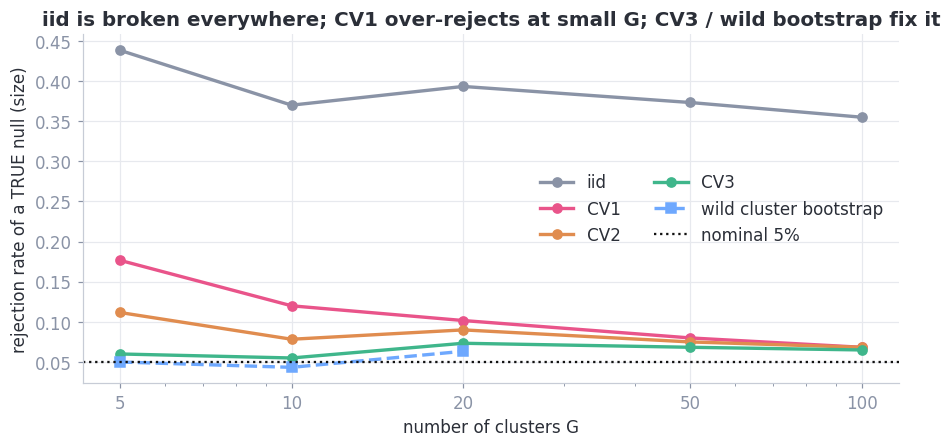

In [8]:
# the money plot: size vs number of clusters
fig, ax = plt.subplots(figsize=(8.4, 4.2))
for m, col in [("iid", GRAY), ("CV1", PINK), ("CV2", ORANGE), ("CV3", GREEN)]:
    ax.plot(Gs, curve[m], "-o", color=col, lw=2.2, label=m)
ax.plot(list(wcr), list(wcr.values()), "--s", color=BLUE, lw=2.2, label="wild cluster bootstrap")
ax.axhline(0.05, color="#111", ls=":", lw=1.5, label="nominal 5%")
ax.set_xscale("log"); ax.set_xticks(Gs); ax.set_xticklabels(Gs)
ax.set_xlabel("number of clusters G"); ax.set_ylabel("rejection rate of a TRUE null (size)")
ax.set_title("iid is broken everywhere; CV1 over-rejects at small G; CV3 / wild bootstrap fix it")
ax.legend(ncol=2); plt.tight_layout(); plt.show()

Read it: **iid** is broken at every $G$ (~0.4). **CV1** is fine at $G\ge50$ but over-rejects badly as
$G$ shrinks (0.17 at $G=5$). **CV3** (jackknife) and the **wild cluster bootstrap** hold ~5% all the way
down — the few-clusters fix.

## 7. Where this bites most — panel data & difference-in-differences

Cross-section clustering was the warm-up. The setting where cluster-robust SEs are *unavoidable* is
**panel data**, and the ubiquitous workhorse is the **clustered two-way fixed-effects (DiD)** regression:
$$Y_{i\textcolor{#E8842C}{g}\textcolor{#2CA02C}{t}} \;=\; \alpha_{\textcolor{#E8842C}{g}} \;+\; \phi_{\textcolor{#2CA02C}{t}}
  \;+\; \theta\,D_{ig\textcolor{#2CA02C}{t}} \;+\; \gamma'\mathbf Z_{igt} \;+\; \varepsilon_{igt},$$
where $\textcolor{#E8842C}{g}=1,\dots,G$ indexes the **group/cluster**, $i$ the **individual**, and
$\textcolor{#2CA02C}{t}$ the **time period**; $\alpha_{\textcolor{#E8842C}{g}}$ is a **group fixed effect**
and $\phi_{\textcolor{#2CA02C}{t}}$ a **time fixed effect**. The coefficient $\theta$ — usually the
parameter of interest — equals the **average treatment effect on the treated (ATT)** under a set of
widely-studied conditions.

> The observations are typically **assumed to be cluster-dependent *within* each group and independent
> *across* groups** — exactly the block-diagonal error structure of §1③. So the SE on $\theta$ must be
> **clustered at the group level**: a panel with few groups is precisely the few-clusters regime where
> CV1 over-rejects and CV3 / the wild cluster bootstrap are needed.

This is why cluster-robust inference is foundational: it's the variance layer under **DiD** (NB 11) and
under **cluster-randomized / switchback** designs (NB 05–06). We build the DiD *estimator* later; here we
built its *standard error*.

## 8. Promote → `lyra/se.py`

We lift the raw functions into `lyra/se.py` (the `ClusterOLS` estimator: iid/CV1/CV2/CV3 + the
`wild_cluster_bootstrap`) and add `ClusteredDGP` to `lyra/dgp`, so the **harness certifies each method's
size/coverage** against the known $\beta$. Recovery + few-clusters checks go in `tests/test_se.py`.
**Next (`ROADMAP.md`): NB 05 — designs & interference** (the marketplace DGP + the money-shot), where
cluster-robust SEs from here are exactly the tool for cluster-randomized analysis.